In [1]:
import kagglehub
import os
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
import seaborn as sns
from PIL import Image
from tqdm import tqdm

In [2]:
# Get the dataset path
path = kagglehub.dataset_download("gpiosenka/sports-classification")

print(f"Dataset location: {path}\n")

Dataset location: C:\Users\Work\.cache\kagglehub\datasets\gpiosenka\sports-classification\versions\9



### Core Statistics

(Add file size checker to see the sizes for all images, the say smt like "imgaes range from xxx to xxx in terms of size")

   class id                 filepaths      labels data set
0         0  train/air hockey/001.jpg  air hockey    train
1         0  train/air hockey/002.jpg  air hockey    train
2         0  train/air hockey/003.jpg  air hockey    train
3         0  train/air hockey/004.jpg  air hockey    train
4         0  train/air hockey/005.jpg  air hockey    train


Contents of directory:
['EfficientNetB0-100-(224 X 224)- 98.40.h5', 'sports.csv', 'sports_improved.csv', 'test', 'train', 'valid']

FOLDER STRUCTURE:

  EfficientNetB0-100-(224 X 224)- 98.40.h5/: 1 files
  sports.csv/: 1 files
  sports_improved.csv/: 1 files
  test/: 500 files
  train/: 13493 files
  valid/: 500 files

FILE TYPES:
  .csv: 2 files
  .h5: 1 files
  .jpg: 14492 files
  .lnk: 1 files
TOTAL IMAGES: 14493
TOTAL CLASSES: 100


C:\Users\Work\AppData\Local\Temp\ipykernel_9880\55050319.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=counts.index, x=counts.values, palette='viridis', legend=False)


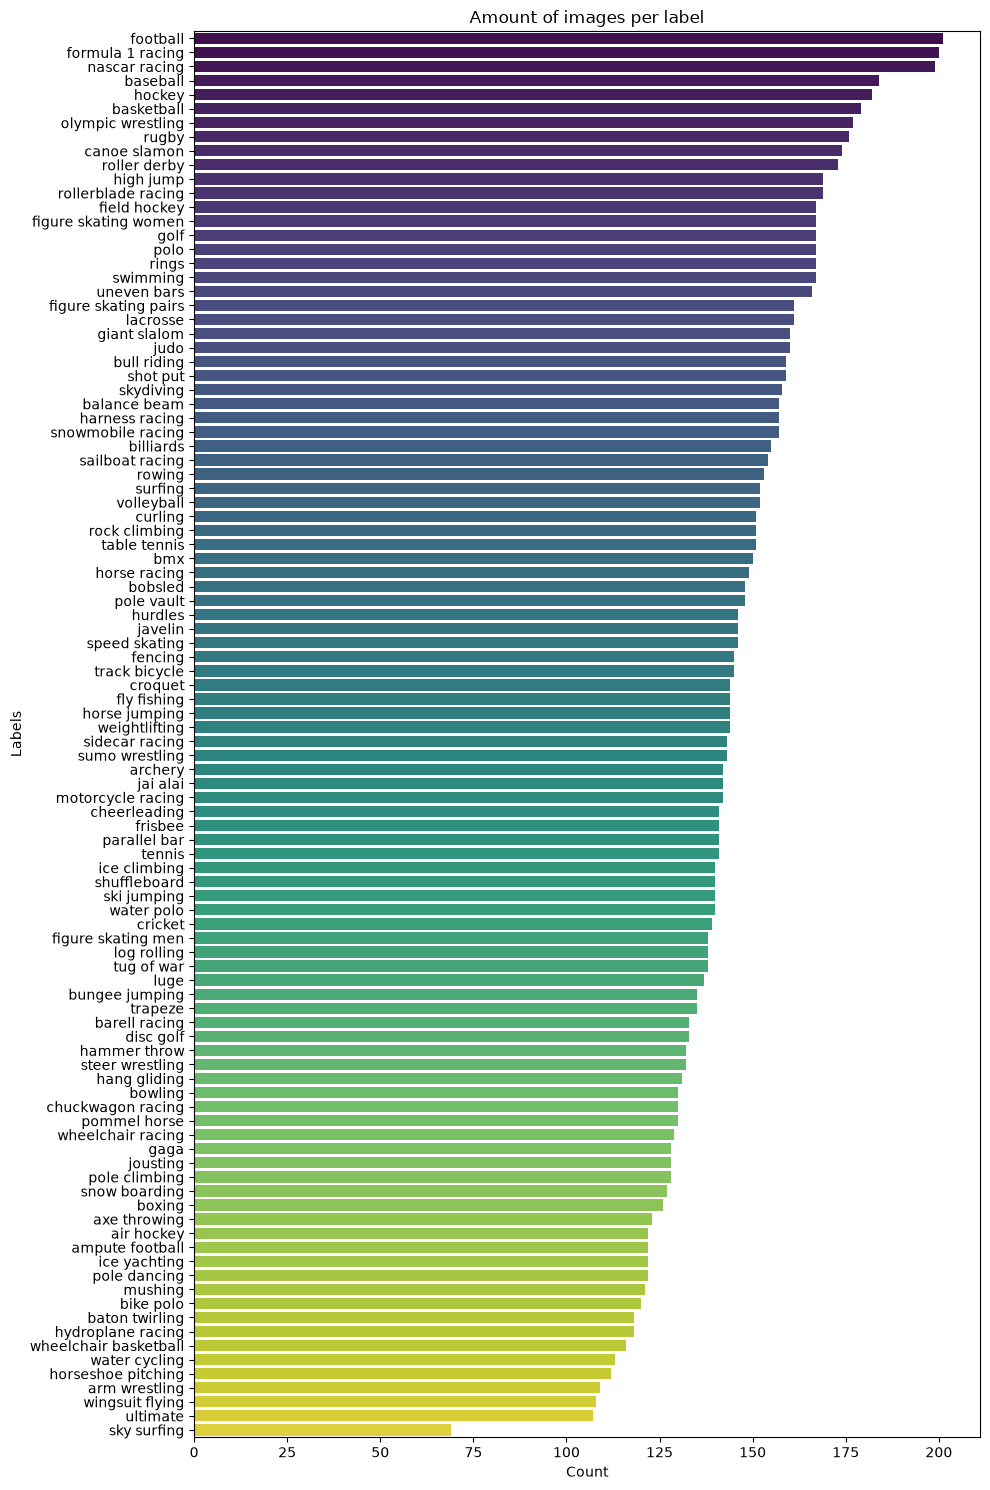

In [3]:
# Load and analyze CSV
df = pd.read_csv(os.path.join(path, "sports.csv"))
print(df.head())
print("\n" + "="*60)

# Analyze folder structure and file types from actual filesystem
print(f"\nContents of directory:")
print(os.listdir(path))

print("\n" + "="*60)
print("FOLDER STRUCTURE:\n")

folder_counts = defaultdict(int)
file_type_counts = defaultdict(int)

for root, dirs, files in os.walk(path):
    for file in files:
        # Get the relative path from path
        rel_path = os.path.relpath(os.path.join(root, file), path)
        top_folder = rel_path.split(os.sep)[0]
        folder_counts[top_folder] += 1
        
        # Get file extension
        _, ext = os.path.splitext(file)
        if ext:  # Only count if there's an extension
            file_type_counts[ext] += 1

for folder in sorted(folder_counts.keys()):
    print(f"  {folder}/: {folder_counts[folder]} files")

print("\nFILE TYPES:")
for ext in sorted(file_type_counts.keys()):
    print(f"  {ext}: {file_type_counts[ext]} files")

# Basic statistics
print(f"TOTAL IMAGES: {len(df)}")
print(f"TOTAL CLASSES: {df['labels'].nunique()}")

# Visualize class distribution
counts = df["labels"].value_counts()
plt.figure(figsize=(10, 15))
sns.barplot(y=counts.index, x=counts.values, palette='viridis', legend=False)
plt.title('Amount of images per label')
plt.ylabel('Labels')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

### Data Quality & Characteristics

In [5]:
# Calculate image sizes
print("\nCalculating image sizes...")
 
def get_image_size(filepath):
    try:
        with Image.open(filepath) as img:
            width, height = img.size
            return [width, height]  # Store as [width, height]
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None
 
df["image_size"] = [
    get_image_size(os.path.join(path, fp)) 
    for fp in tqdm(df["filepaths"], desc="Files")
]
 
# Display statistics
print(f"\nImage sizes added!")
 
# Extract widths and heights for statistics
widths = df["image_size"].apply(lambda x: x[0] if x else None)
heights = df["image_size"].apply(lambda x: x[1] if x else None)
pixel_counts = df["image_size"].apply(lambda x: x[0] * x[1] if x else None)
 
print(f"Width  - Min: {widths.min()}, Max: {widths.max()}, Mean: {widths.mean():.0f}")
print(f"Height - Min: {heights.min()}, Max: {heights.max()}, Mean: {heights.mean():.0f}")
print(f"Resolution - Min: {pixel_counts.min()}, Max: {pixel_counts.max()}, Mean: {pixel_counts.mean():.0f}")
print(f"Missing sizes: {df['image_size'].isna().sum()} images")


Calculating image sizes...


Files:  40%|████      | 5807/14493 [00:03<00:06, 1402.37it/s]

Error reading C:\Users\Work\.cache\kagglehub\datasets\gpiosenka\sports-classification\versions\9\train/high jump/159.lnk: cannot identify image file 'C:\\Users\\Work\\.cache\\kagglehub\\datasets\\gpiosenka\\sports-classification\\versions\\9\\train/high jump/159.lnk'


Files: 100%|██████████| 14493/14493 [00:08<00:00, 1675.25it/s]


Image sizes added!
Width  - Min: 224.0, Max: 224.0, Mean: 224
Height - Min: 224.0, Max: 224.0, Mean: 224
Resolution - Min: 50176.0, Max: 50176.0, Mean: 50176
Missing sizes: 1 images


### Class-Specific Insights

In [ ]:
# Per-class statistics:
    # DONE Number of images per class
    # UNNECESARY Mean/min/max image dimensions per class
    # DONE Class imbalance ratio (largest class / smallest class)
# Identify minority/majority classes

# Class imbalance
# class_imbalance = df.groupby('labels').size().reset_index(name='count').max() / df.groupby('labels').size().reset_index(name='count').min()
grouped = df.groupby('labels').size().reset_index(name='count')
max_idx = grouped['count'].idxmax()
min_idx = grouped['count'].idxmin()

max_row = grouped.loc[max_idx]
name_max = max_row['labels']
count_max = max_row['count']

min_row = grouped.loc[min_idx]
name_min = min_row['labels']
count_min = min_row['count']

print(f"The {name_max} class ({count_max} images) is {count_max/count_min:.2f} times bigger than the {name_min} class ({count_min} images).")

### The code that's below here, is stuff that I'm working on atm, it doesn't have a "category"

In [ ]:
# Load and display an image
img_path = os.path.join(path, "test/air hockey/1.jpg")
img = imread(img_path)

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')
plt.title("Air Hockey")
plt.show()

In [ ]:
labels = df["labels"].unique()
print(labels)

In [ ]:
# Get summary stats
summary = df.groupby('labels').size().reset_index(name='count')
summary = summary.sort_values('count', ascending=False)
print(summary[0:10])

In [ ]:
# List of sports you want
sports_list = ['football', 'formula 1 racing', 'hockey']

# Filter dataframe
filtered_df = df[df['labels'].isin(sports_list)]

print(filtered_df["labels"].unique())
print(f"\nOriginal: {len(df)} rows")
print(f"Filtered: {len(filtered_df)} rows")
print(filtered_df.columns)
print(filtered_df.head())